In [2]:
from datasets import load_dataset

import numpy as np
import torch
import matplotlib.pyplot as plt
from configurations.plot_config import set_font_sizes, apply_general_styles, create_fig, FONTSIZES
from configurations.data_config import make_params_dict , load_data, save_fig, save_data

from attention_nn.dataset import get_all_sentences, build_tokenizer, get_dataloader, get_random_dataloader
from attention_nn.model import create_model

apply_general_styles()

/u/c/cerazova/miniconda3/envs/transf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Bigram

In [5]:
# Define configuration
config = {
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 1,
    'L': 128,
    'datasource': 'roneneldan/TinyStories',
}

# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
vocab_size = tokenizer.get_vocab_size()
print(f'Vocabulary size = {vocab_size}. Maximum entropy per token = {np.log(vocab_size):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")


Preparing data loaders...


Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.


In [6]:
# Measure token frequency in all dataset for each position in sequence
data_stats = {}
token_counts = np.zeros((config['L'], vocab_size))

for batch in train_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1
for batch in val_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1

# Eliminate data from padding tokens
token_counts[:, pad_id] = 0
data_stats['unsorted_token_counts'] = token_counts.copy()

total_counts = token_counts.sum(axis=0)  # (vocab_size,)
sorted_tokens = np.argsort(-total_counts)  # Indices of tokens sorted by frequency descending
token_counts = token_counts[:, sorted_tokens]  # Sort token counts accordingly
total_counts = total_counts[sorted_tokens]

# Compute entropy per position
token_frequencies = token_counts / token_counts.sum(axis=1, keepdims=True)  # (L, vocab_size)
entropies = -np.nansum(token_frequencies * np.log(token_frequencies + 1e-12), axis=1)  # (L,)

# Compute total entropy
total_token_frequencies = total_counts / total_counts.sum()
total_entropy = -np.nansum(total_token_frequencies * np.log(total_token_frequencies + 1e-12))

data_stats['sorted_token_counts'] = token_counts.copy()
data_stats['sorted_tokens'] = sorted_tokens
data_stats['entropies_per_position'] = entropies
data_stats['total_entropy'] = total_entropy
data_stats['sorted_rank'] = np.argsort(sorted_tokens)


In [7]:
# Compute the bigram distribution of tokens in the training set
print('Computing bigram distribution...')
bigram = np.zeros((vocab_size, vocab_size))  # Initialize with zeros
total_bigrams = 0
for batch in train_dataloader:
    input_ids = batch['input'].squeeze(0).numpy()  # Remove batch dimension
    # Iterate through the sequence to count bigrams
    for i in range(len(input_ids) - 1):
        token1 = input_ids[i]
        token2 = input_ids[i + 1]
        if token1 != pad_id or token2 != pad_id:
            bigram[token1, token2] += 1
            total_bigrams += 1

for batch in val_dataloader:
    input_ids = batch['input'].squeeze(0).numpy()  # Remove batch dimension
    # Iterate through the sequence to count bigrams
    for i in range(len(input_ids) - 1):
        token1 = input_ids[i]
        token2 = input_ids[i + 1]
        if token1 != pad_id or token2 != pad_id:
            bigram[token1, token2] += 1
            total_bigrams += 1

bigram /= total_bigrams  # Normalize to get probabilities

# Conditional bigram distribution P(token2 | token1)
normalization = bigram.sum(axis=1, keepdims=True)
# To avoid division by zero, set zero rows to one before division
normalization[normalization == 0] = 1
conditional_bigram = bigram / normalization

data_stats['bigram'] = bigram
data_stats['unigram'] = bigram.sum(axis=1)
data_stats['conditional_bigram'] = conditional_bigram
data_stats['bigram_entropy'] = -np.nansum(bigram * np.log(bigram + 1e-12))

for key, value in data_stats.items():
    print(f'{key}: {value.shape}')

names = ['dataset_size','L']
params = {k: config[k] for k in names}
save_data(data_stats,'token_details','data_statistics',params=params,base_dir='../data')

Computing bigram distribution...
unsorted_token_counts: (128, 8043)
sorted_token_counts: (128, 8043)
sorted_tokens: (8043,)
entropies_per_position: (128,)
total_entropy: ()
sorted_rank: (8043,)
bigram: (8043, 8043)
unigram: (8043,)
conditional_bigram: (8043, 8043)
bigram_entropy: ()
File saved with pickle.dump on /u/c/cerazova/Transformers/data/data_statistics as token_details_L128_dataset_size10000.pkl


# Measures

In [90]:
# Fixed Model Parameters
d = 512
dataset_size = 10000
L = 128
rank = None
batch_size = 64
num_epochs = 10

# Architectural Parameters
skip_residual = False
fr_emb = False
fr_att = False

# Hyperparameters
beta = 1.0
lr = 0.05

# Load data statistics
params = {'dataset_size': dataset_size, 'L': L}
data_stats = load_data('token_details','data_statistics',params=params,base_dir='../data')
total_entropy = data_stats['total_entropy']
entropies = data_stats['entropies_per_position']
total_token_frequencies = data_stats['sorted_token_counts']/data_stats['sorted_token_counts'].sum()
entropy_unigram = data_stats['total_entropy']
entropy_bigram = data_stats['bigram_entropy']


# Loop over various configurations  =  amp, type_enc,  unmb
sigma = 0.5
amp = 1.0
type_enc = 'learned'
unmb = True


fix_names = ['rank','d','L','dataset_size','skip_residual','fr_att','fr_emb','batch_size','lr','beta']
var_names = ['type_enc','amp','unmb','sigma']
params = make_params_dict(fix_names , var_names)


summary_scalar = load_data('summary_log',experiment_name='new_evolution_scalar', params=params)
summary_matrices = load_data('summary_log',experiment_name='new_evolution_matrices', params=params)


print('In scalar summary:')
for key in summary_scalar.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary_scalar[key].shape}')

bs = batch_size
n = dataset_size

File token_details_L128_dataset_size10000.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/data_statistics
File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_scalar/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_matrices/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
In scalar summary:
evaluation_steps: (83,)
train_loss: (83,)
val_loss: (83,)
entropy: (83, 5)
part_ratio: (83, 5)
pos_attended: (83, 5)
pred_entropy: (83, 128)
att_in_fractions: (83, 5, 128)
KL_uniform: (83,)
KL_tot: (83,)
KL_mu: (83,)
KL_bigram: (83,)
average_rank: (83, 5)
embedd_eigvals: (83, 512)
embedd_mean: (83,)
embedd_std: (83,)
W_eigvals: (83, 512)
W_mean: (83,)
W_std:

Figure saved on /u/c/cerazova/Transformers/plots/2026-02 as new_training_curve_L128_amp1_bs64_d512_lr0.05_n10000_sigma0.5_type_enclearned_unmbTrue.png


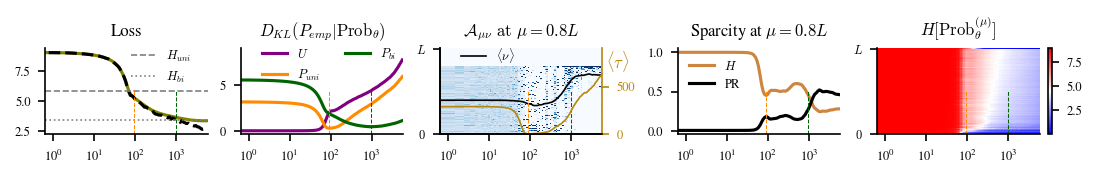

In [92]:
# Setup and variables
step_scalar = summary_scalar['evaluation_steps']
vocab_size = int(summary_scalar['vocab_size'])
sequence_fractions = summary_scalar['sequence_fractions']
i_seq_frac = 3
f = sequence_fractions[i_seq_frac]
idx_uni = np.argmin(summary_scalar['KL_tot'])
idx_bigram = np.argmin(summary_scalar['KL_bigram'])

summary_scalar['PR_f'] = summary_scalar['part_ratio'][:,i_seq_frac]
summary_scalar['H_f'] = summary_scalar['entropy'][:,i_seq_frac]
summary_scalar['pos_attnd'] = L*f*summary_scalar['pos_attended'][:,i_seq_frac]
summary_scalar['av_rnk'] = summary_scalar['average_rank'][:, i_seq_frac]
summary_scalar['att_pattern'] = summary_scalar['att_in_fractions'][:,i_seq_frac]
seq_range = np.arange(0, L)
# plt.rcParams['text.usetex'] = False

col_unig = 'darkorange'
col_bigr = 'darkgreen'

lines_plots = {
    'Loss': [{'var':'val_loss','color':'olive','ls':'-','label':''},
             {'var':'train_loss','color':'k','ls':'--','label':''}],  
    r'$D_{KL}(P_{emp}|\text{Prob}_\theta)$': [{'var':'KL_uniform','color':'purple','ls':'-', 'label':r'$U$'},
                       {'var':'KL_tot','color':col_unig,'ls':'-','label':r'$P_{uni}$'},
                       {'var':'KL_bigram','color':col_bigr,'ls':'-','label':r'$P_{bi}$'} ],
    rf'$\mathcal{{A}}_{{\mu \nu}} \text{{ at }} {{\mu = {f}L}}$': [
                                        {'var': 'pos_attnd', 'color': 'k', 'ls': '-', 'label': r'$\langle \nu \rangle$','lw':0.8},
                                        {'var': 'av_rnk', 'color': 'darkgoldenrod', 'ls': '-', 'label': r'$\langle \tau \rangle$','lw':0.8},
    ],
    fr'Sparcity at ${{\mu = {f}L}}$': [{'var':'H_f','color':'peru','ls':'-','label':r'$H$'},
                                      {'var':'PR_f','color':'k','ls':'-','label':'PR'} ],
}

img_plots = {
        rf'$\mathcal{{A}}_{{\mu \nu}} \text{{ at }} {{\mu = {f}L}}$': {'matrix':'att_pattern','cmap':'Blues','vmin':None,'vmax':0.04,'colorbar':False},
        r'$H[\text{Prob}_\theta^{(\mu)}]$' : {'matrix':'pred_entropy','cmap':'bwr','vmin':None,'vmax':None,'colorbar':True},
}

leg_config = [
    {'ncols':1,'loc':(0.5,0.52)},
    {'ncols':2,'loc':(0.1,0.55)},
    {'ncols':1,'loc':(0.1,0.75)},
    {'ncols':1,'loc':'best'},

]

idx_lines = [0,1,2,3]
idx_img = [2,4]
set_font_sizes(conf='tight')


# Create figure
fig , axes = create_fig(nrows=1,ncols=5,size='double',h=0.15)


# Plot lines
for i , title in enumerate(lines_plots.keys()):
    ax = axes[idx_lines[i]]
    ax.set_title(title, fontsize=FONTSIZES['s'])
    for setting in lines_plots[title]:
        conf = {key: setting[key] for key in setting.keys() - {'var'}}
        if setting['var'] == 'av_rnk':
            ax2 = ax.twinx()
            ax2.spines['right'].set_visible(True)
            ax2.spines['right'].set_color(setting['color'])
            ax2.tick_params(axis='y', colors=setting['color'])
            ax2.set_ylabel(r'$\langle\tau\rangle$', color=setting['color'], loc='top' ,labelpad=-3, rotation=0, fontsize=FONTSIZES['s'])
            ax = ax2
        ax.plot('evaluation_steps',setting['var'],data=summary_scalar, **conf)


# Plot images
for i , title in enumerate(img_plots.keys()):
    ax = axes[idx_img[i]]
    ax.set_title(title, fontsize=FONTSIZES['s'])
    ax.set_yticks([0,L-1],[r'$0$',r'$L$'])
    setting = img_plots[title]
    matrix = summary_scalar[setting['matrix']]
    conf = {key: setting[key] for key in setting.keys() - {'matrix','colorbar'}}
    mesh = ax.pcolormesh(step_scalar,seq_range, matrix.T, **conf)
    if setting['colorbar']:
        cbar = fig.colorbar(mesh, ax=ax)
        cbar.ax.tick_params(labelsize=FONTSIZES['xs'])

for l , ls, lbl in zip([entropy_unigram, entropy_bigram-entropy_unigram],['--',':'], [r'$H_{uni}$',r'$H_{bi}$']):
    axes[0].axhline(l, color='gray', ls=ls, lw=0.8, label=lbl)

for i , ax in enumerate(axes):
    ax.axvline(step_scalar[idx_uni], ymax=0.5,color=col_unig, ls='--', lw=0.5)
    ax.axvline(step_scalar[idx_bigram], ymax = 0.5,color=col_bigr, ls='--', lw=0.5)
    ax.set_xscale('log')
    ax.tick_params(axis='x', which='minor',  bottom=False)
    # Plot legend only if there are lines to show
    if i != 4:
        ax.legend(frameon=False,**leg_config[i])

ax2.set_ylim(bottom=0,top=900)
axes[1].set_ylim(top=9)


names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
save_fig(fig,'new_training_curve',params=params,date=True)


In [ ]:
ax.legend

array([<Axes: title={'center': 'Loss'}>,
       <Axes: title={'center': '$D_{KL}(P_{emp}|\\text{Prob}_\\theta)$'}>,
       <Axes: title={'center': '$\\mathcal{A}_{\\mu \\nu} \\text{ at } {\\mu = 0.8L}$'}>,
       <Axes: title={'center': 'Sparcity at ${\\mu = 0.8L}$'}>,
       <Axes: title={'center': '$H[\\text{Prob}_\\theta^{(\\mu)}]$'}>],
      dtype=object)

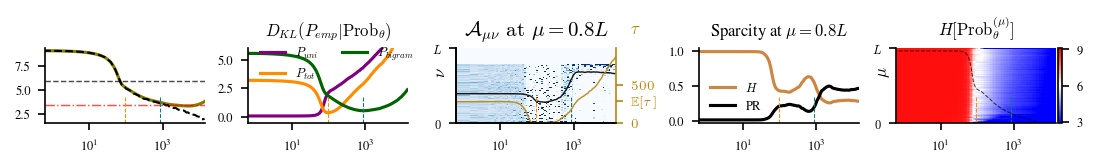

In [ ]:
# Setup and variables
step_scalar = summary_scalar['evaluation_steps']
vocab_size = int(summary_scalar['vocab_size'])
sequence_fractions = summary_scalar['sequence_fractions']
i_seq_frac = 3
f = sequence_fractions[i_seq_frac]
idx_uni = np.argmin(summary_scalar['KL_tot'])
idx_bigram = np.argmin(summary_scalar['KL_bigram'])
lbls = True

plt.rcParams['text.usetex'] = False

set_font_sizes(conf='tight')


# Create figure
fig , axes = create_fig(nrows=1,ncols=5,size='double',h=0.14 if lbls else 0.12) # h=0.15



# Loss
ax = axes[0]
ax.plot(step_scalar,summary_scalar['val_loss'], color='olive',ls='-')
ax.plot(step_scalar,summary_scalar['train_loss'], color='k',ls='--',lw=1)
ax.axhline(entropy_unigram, color='k', ls='--', lw=.7, label=r'$H_{uni}$',alpha=0.7)
ax.axhline(entropy_bigram-entropy_unigram, color='red', ls='-.', lw=.7, label=r'$H_{bigram}$',alpha=0.7)
ax.set_ylim(bottom=1.5,top=9.3)
# yticks = [4,6,8]
# ylabels = [f'{y:.1f}' for y in yticks]
# ax.set_yticks([*yticks,np.log(vocab_size)], [*ylabels, r'$\log V$'])
# if lbls:
#     ax.set_title('Val Loss',size=FONTSIZES['s'])
#     ax.legend(frameon=False,ncols=1,loc=(0.45,0.5))


# KL divergences
ax = axes[1]
ax.plot(step_scalar,summary_scalar['KL_uniform'], label=r'$P_{uni}$', color='purple',ls='-')
ax.plot(step_scalar,summary_scalar['KL_tot'], label=r'$P_{tot}$', color='darkorange',ls='-')
# ax.plot(step_scalar,summary_scalar['KL_mu'], label=r'$P_{\mu}$', color='teal',ls='-')
ax.plot(step_scalar,summary_scalar['KL_bigram'], label=r'$P_{bigram}$', color='darkgreen',ls='-')
ax.set_ylim(top=6)
if lbls:
    ax.set_title(r'$D_{KL}(P_{emp}|\text{Prob}_\theta)$',size=FONTSIZES['s'])
    ax.legend(frameon=False,ncols=2,loc=(0.04,0.49))


# Sparcity Measures
ax = axes[3]
ax.plot(step_scalar, summary_scalar['entropy'][:,i_seq_frac], label=r'$H$', color='peru',ls='-')
ax.plot(step_scalar, summary_scalar['part_ratio'][:,i_seq_frac], label='PR', color='k',ls='-')
if lbls:
    ax.set_title(fr'Sparcity at ${{\mu = {f}L}}$',size=FONTSIZES['s'])
    ax.legend(frameon=False,ncols=1)

# Prediction Entropy
ax = axes[4]
vmin , vmax = 2.9 , 9.1
cmesh = ax.pcolormesh(step_scalar, np.arange(config['L']), summary_scalar['pred_entropy'].T, cmap='bwr',vmax=vmax,vmin=vmin)
av_entropy = summary_scalar['pred_entropy'].mean(axis=1)
av_entropy = (av_entropy - vmin) * (config['L']-1) / (vmax - vmin)
ax.plot(step_scalar, av_entropy, color='k',ls='--',lw=0.5,alpha=0.7)
ax.set_ylim(0,L)
ax.set_yticks([0,L],['$0$','$L$'])
clb = plt.colorbar(cmesh,ax=ax,fraction=0.16, pad=0.01)
clb.set_ticks([3,6,9])
if lbls:
    ax.set_title(r'$H[\text{Prob}_\theta^{(\mu)}]$',size=FONTSIZES['s'])


# Attention Pattern
ax = axes[2]
attention_patterns = summary_scalar['att_in_fractions']  # (num_step_scalars, len(seq_fract), L)
mesh = ax.pcolormesh(step_scalar, np.arange(L), attention_patterns[:, i_seq_frac].T,cmap='Blues',vmax=0.04)
ax.plot(step_scalar,L*f*summary_scalar['pos_attended'][:,i_seq_frac], 
        label=r'$\langle \;\nu \rangle$', color='k',ls='-',lw=0.7,alpha=0.9)
ax.set_ylim(0,L)
ax.set_yticks([0,L],['$0$','$L$'])
plt.rcParams['text.usetex'] = True
ax2 = ax.twinx()

col = 'darkgoldenrod'
ax2.plot(step_scalar, summary_scalar['average_rank'][:, i_seq_frac], alpha=0.9,ls='-',
         label=r'$\mathrm{Avg. \; Rank}$', color=col, lw=0.7)
ax2.tick_params(axis='y', colors=col)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(col)
ax2.set_ylim(0, 990)
tau_av = (total_token_frequencies*np.arange(vocab_size)).sum()
ax2.set_yticks([0,tau_av,500],['0',r'$\mathbb{E}[\tau]$','500'])
plt.rcParams['text.usetex'] = False

if lbls:
    ax.set_title(rf'$\mathcal{{A}}_{{\mu \nu}} \text{{ at }} {{\mu = {f}L}}$')

ax.set_xscale('log')
lbs = ['(a)','(b)','(c)','(d)','(e)']
locs = np.linspace(0.02,1,6)[:-1]
for i in [0,1,2,3,4]:
    ax = axes[i]
    # Do the lines until half heigth of the current y-axis
    ylims = ax.get_ylim()
    ax.set_ylim(ylims)
    # Eliminate just minor ticks keeping major ticks and
    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False,size=FONTSIZES['xxs'])
    ax.plot([step_scalar[idx_uni], step_scalar[idx_uni]], [ylims[0],ylims[0]+(ylims[1]-ylims[0])*0.35], color='darkorange', ls='--', lw=0.5)
    ax.plot([step_scalar[idx_bigram], step_scalar[idx_bigram]], [ylims[0],ylims[0]+(ylims[1]-ylims[0])*0.35], color='teal', ls='--', lw=0.5)
    # fig.text(locs[i],1.02,lbs[i], fontsize=FONTSIZES['s'], va='center', ha='center', color='k',transform=fig.transFigure)





# fig.text(0.98,0.03,'Step', fontsize=FONTSIZES['s'], va='center', ha='center', transform=fig.transFigure)
fig.text(0.58,0.86,r'$\tau$', fontsize=FONTSIZES['s'], va='center', ha='center', color=col,transform=fig.transFigure)
fig.text(0.4,0.58,r'$\nu$', rotation=90,fontsize=FONTSIZES['s'], va='center', ha='center', color='k',transform=fig.transFigure)
fig.text(0.81,0.58,r'$\mu$', rotation=90,fontsize=FONTSIZES['s'], va='center', ha='center', color='k',transform=fig.transFigure)


names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
# save_fig(fig,'training_curve_nolb',params=params,date=True)